# Prediction on Original Dataset

Notebook ini digunakan untuk melakukan prediksi terhadap seluruh audio asli pada Dataset_Final_Indonesia.

Output:

- Filename
- Actual Emotion
- Predicted Emotion
- Confidence
- Prediction Status

In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

import os

import librosa

import numpy as np

import pandas as pd

from tqdm import tqdm

from tensorflow.keras.models import load_model

In [2]:
# ==========================================================
# CREATE MEL SPECTROGRAM
# ==========================================================

def create_mel_spectrogram(audio, sr):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    return mel_db

In [3]:
# ==========================================================
# LOAD MODEL
# ==========================================================

model = load_model(

    "ser_model_augmented.keras"

)

print(

    "Model loaded successfully."

)

Model loaded successfully.


In [4]:
# ==========================================================
# LABEL NAME
# ==========================================================

emotion_map = {

    "01_Anger": "Anger",

    "02_Sadness": "Sadness",

    "03_Neutral": "Neutral",

    "04_Happiness": "Happiness"

}

In [5]:
# ==========================================================
# IMPORT AUDIO PROCESSING
# ==========================================================

from audio_processing import (

    load_audio,

    save_mel_spectrogram,

    extract_feature

)

In [6]:
# ==========================================================
# DATASET CONFIGURATION
# ==========================================================

dataset_path = "Dataset_Final_Indonesia"

emotion_folders = {

    "01_Anger": "Anger",

    "02_Sadness": "Sadness",

    "03_Neutral": "Neutral",

    "04_Happiness": "Happiness"

}

In [7]:
# ==========================================================
# LOAD SINGLE AUDIO
# ==========================================================

folder = "01_Anger"

file_name = sorted(

    os.listdir(

        os.path.join(

            dataset_path,

            folder

        )

    )

)[0]

audio_path = os.path.join(

    dataset_path,

    folder,

    file_name

)

print(audio_path)

Dataset_Final_Indonesia\01_Anger\anger001.wav


In [8]:
# ==========================================================
# LOAD AUDIO
# ==========================================================

audio, sr, duration = load_audio(

    audio_path

)

print(

    "Duration :", duration

)

print(

    "Sampling Rate :", sr

)

print(

    "Audio Shape :", audio.shape

)

Duration : 1.63
Sampling Rate : 16000
Audio Shape : (26022,)


In [9]:
# ==========================================================
# LOAD SINGLE AUDIO
# ==========================================================

folder = "01_Anger"

file_name = sorted(

    os.listdir(

        os.path.join(

            dataset_path,

            folder

        )

    )

)[0]

audio_path = os.path.join(

    dataset_path,

    folder,

    file_name

)

print(audio_path)

Dataset_Final_Indonesia\01_Anger\anger001.wav


In [10]:
# ==========================================================
# AUDIO PREPROCESSING
# ==========================================================

audio, sr, duration = load_audio(

    audio_path

)

mel_db = create_mel_spectrogram(
    audio,
    sr
)

X = extract_feature(

    mel_db

)

print(

    X.shape

)

(1, 128, 215, 1)


In [11]:
# ==========================================================
# SINGLE PREDICTION
# ==========================================================

prediction = model.predict(

    X,

    verbose=0

)

predicted_index = np.argmax(

    prediction

)

confidence = np.max(

    prediction

) * 100

label_names = [

    "Anger",

    "Sadness",

    "Neutral",

    "Happiness"

]

print(

    "Filename :", file_name

)

print(

    "Actual :", emotion_folders[folder]

)

print(

    "Prediction :", label_names[predicted_index]

)

print(

    f"Confidence : {confidence:.2f}%"

)

Filename : anger001.wav
Actual : Anger
Prediction : Sadness
Confidence : 43.63%


In [12]:
# ==========================================================
# PREDICTION ON ORIGINAL DATASET
# ==========================================================

label_names = [

    "Anger",

    "Sadness",

    "Neutral",

    "Happiness"

]

results = []

for folder, actual_emotion in emotion_folders.items():

    folder_path = os.path.join(

        dataset_path,

        folder

    )

    audio_files = sorted(

        os.listdir(folder_path)

    )

    print(f"Processing {folder}...")

    for file_name in tqdm(audio_files):

        audio_path = os.path.join(

            folder_path,

            file_name

        )

        try:

            audio, sr, duration = load_audio(

                audio_path

            )

            mel_db = create_mel_spectrogram(

                audio,

                sr

            )

            X = extract_feature(

                mel_db

            )

            prediction = model.predict(

                X,

                verbose=0

            )

            predicted_index = np.argmax(

                prediction

            )

            predicted_emotion = label_names[

                predicted_index

            ]

            confidence = round(

                float(

                    np.max(prediction)

                ) * 100,

                2

            )

            results.append({

                "Filename": file_name,

                "Actual": actual_emotion,

                "Predicted": predicted_emotion,

                "Confidence": confidence,

                "Correct": actual_emotion == predicted_emotion,

                "Duration": duration

            })

        except Exception as e:

            print(

                f"Error : {file_name}"

            )

            print(e)

Processing 01_Anger...


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:52<00:00,  7.55it/s]


Processing 02_Sadness...


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:52<00:00,  7.57it/s]


Processing 03_Neutral...


 90%|███████████████████████████████████████████████████████████████████████▊        | 414/461 [00:58<00:06,  6.96it/s]C:\Users\hafiz\SER_Skripsi\audio_processing.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
C:\Users\hafiz\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|████████████████████████████████████████████████████████████████████████████████| 461/461 [01:06<00:00,  6.95it/s]


Processing 04_Happiness...


100%|████████████████████████████████████████████████████████████████████████████████| 460/460 [01:01<00:00,  7.43it/s]


In [13]:
# ==========================================================
# BUILD RESULT DATAFRAME
# ==========================================================

result_df = pd.DataFrame(

    results

)

result_df.head()

,Filename,Actual,Predicted,Confidence,Correct,Duration
0,anger001.wav,Anger,Sadness,43.63,False,1.63
1,anger002.wav,Anger,Sadness,45.83,False,3.29
2,anger003.wav,Anger,Anger,84.66,True,1.92
3,anger004.wav,Anger,Anger,81.91,True,1.29
4,anger005.wav,Anger,Anger,46.33,True,1.71


In [14]:
# ==========================================================
# DATASET SUMMARY
# ==========================================================

print(

    "Total Audio :", 

    len(result_df)

)

print()

print(

    result_df["Correct"].value_counts()

)

Total Audio : 1721

Correct
True     1192
False     529
Name: count, dtype: int64


In [15]:
# ==========================================================
# ACCURACY
# ==========================================================

accuracy = (

    result_df["Correct"]

    .mean()

) * 100

print(

    f"Dataset Accuracy : {accuracy:.2f}%"

)

Dataset Accuracy : 69.26%


In [16]:
# ==========================================================
# WRONG PREDICTION
# ==========================================================

wrong_prediction = result_df[

    result_df["Correct"] == False

]

wrong_prediction.head(20)

,Filename,Actual,Predicted,Confidence,Correct,Duration
0,anger001.wav,Anger,Sadness,43.63,False,1.63
1,anger002.wav,Anger,Sadness,45.83,False,3.29
5,anger006.wav,Anger,Neutral,49.88,False,3.17
6,anger007.wav,Anger,Neutral,58.36,False,3.00
29,anger030.wav,Anger,Sadness,33.85,False,2.42
30,anger031.wav,Anger,Sadness,68.55,False,1.71
32,anger033.wav,Anger,Neutral,42.88,False,3.29
34,anger035.wav,Anger,Neutral,45.06,False,2.34
37,anger038.wav,Anger,Neutral,44.87,False,1.63
38,anger039.wav,Anger,Neutral,36.82,False,1.88


In [17]:
# ==========================================================
# TOP WRONG CONFIDENCE
# ==========================================================

wrong_prediction.sort_values(

    by="Confidence",

    ascending=False

).head(20)

,Filename,Actual,Predicted,Confidence,Correct,Duration
1701,happiness441.wav,Happiness,Neutral,99.78,False,3.02
1628,happiness368.wav,Happiness,Neutral,97.95,False,3.08
1637,happiness377.wav,Happiness,Neutral,92.64,False,3.02
1644,happiness384.wav,Happiness,Neutral,91.14,False,3.01
1283,happiness023.wav,Happiness,Sadness,90.72,False,1.50
1661,happiness401.wav,Happiness,Neutral,90.38,False,3.02
1656,happiness396.wav,Happiness,Anger,88.75,False,2.92
1402,happiness142.wav,Happiness,Neutral,88.37,False,5.04
946,neutral147.wav,Neutral,Sadness,88.35,False,1.62
187,anger188.wav,Anger,Neutral,88.30,False,4.04


In [18]:
# ==========================================================
# ACCURACY PER EMOTION
# ==========================================================

emotion_accuracy = (

    result_df

    .groupby("Actual")["Correct"]

    .mean()

    * 100

).round(2)

emotion_accuracy = emotion_accuracy.reset_index()

emotion_accuracy.columns = [

    "Emotion",

    "Accuracy (%)"

]

emotion_accuracy

,Emotion,Accuracy (%)
0,Anger,72.50
1,Happiness,51.09
2,Neutral,65.29
3,Sadness,91.50


In [19]:
# ==========================================================
# PREDICTION DISTRIBUTION
# ==========================================================

prediction_distribution = (

    result_df

    .groupby(

        ["Actual", "Predicted"]

    )

    .size()

    .reset_index(name="Total")

)

prediction_distribution

,Actual,Predicted,Total
0,Anger,Anger,290
1,Anger,Happiness,19
2,Anger,Neutral,38
3,Anger,Sadness,53
4,Happiness,Anger,48
5,Happiness,Happiness,235
6,Happiness,Neutral,92
7,Happiness,Sadness,85
8,Neutral,Anger,28
9,Neutral,Happiness,23


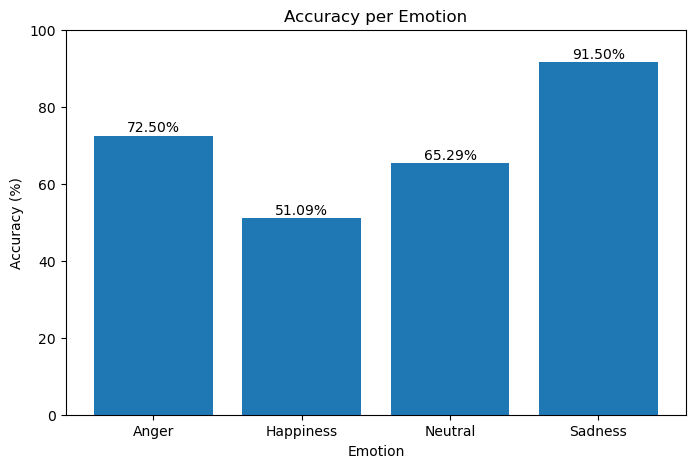

In [20]:
# ==========================================================
# ACCURACY PER EMOTION CHART
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(

    emotion_accuracy["Emotion"],

    emotion_accuracy["Accuracy (%)"]

)

plt.title(

    "Accuracy per Emotion"

)

plt.xlabel(

    "Emotion"

)

plt.ylabel(

    "Accuracy (%)"

)

plt.ylim(

    0,

    100

)

for i, value in enumerate(

    emotion_accuracy["Accuracy (%)"]

):

    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"

    )

plt.show()

In [21]:
# ==========================================================
# EXPORT RESULT
# ==========================================================

result_df.to_csv(

    "prediction_result.csv",

    index=False

)

print(

    "prediction_result.csv berhasil disimpan."

)

prediction_result.csv berhasil disimpan.


In [22]:
# ==========================================================
# EXPORT WRONG PREDICTION
# ==========================================================

wrong_prediction.to_csv(

    "wrong_prediction.csv",

    index=False

)

print(

    "wrong_prediction.csv berhasil disimpan."

)

wrong_prediction.csv berhasil disimpan.


# Test Audio Eksternal

In [70]:
# ==========================================================
# TEST EXTERNAL AUDIO
# ==========================================================

audio_path = "HappTest51.wav"

print(audio_path)

HappTest51.wav


In [71]:
# ==========================================================
# LOAD AUDIO
# ==========================================================

audio, sr, duration = load_audio(audio_path)

print(f"Duration : {duration:.2f} s")
print(f"Sampling Rate : {sr}")

Duration : 2.76 s
Sampling Rate : 16000


In [72]:
# ==========================================================
# CREATE MEL SPECTROGRAM
# ==========================================================

mel_db = create_mel_spectrogram(
    audio,
    sr
)

X = extract_feature(
    mel_db
)

print(X.shape)

(1, 128, 215, 1)


In [73]:
# ==========================================================
# MODEL PREDICTION
# ==========================================================

prediction = model.predict(
    X,
    verbose=0
)

label_names = [

    "Anger",

    "Sadness",

    "Neutral",

    "Happiness"

]

predicted_index = np.argmax(
    prediction
)

print("=" * 50)

print(
    "Prediction :",
    label_names[predicted_index]
)

print(
    "Confidence :",
    round(
        float(
            np.max(prediction)
        ) * 100,
        2
    ),
    "%"
)

print("=" * 50)

Prediction : Happiness
Confidence : 85.35 %


In [74]:
# ==========================================================
# ALL PROBABILITY
# ==========================================================

for label, prob in zip(
    label_names,
    prediction[0]
):

    print(
        f"{label:12s} : {prob*100:.2f}%"
    )

Anger        : 9.85%
Sadness      : 1.71%
Neutral      : 3.10%
Happiness    : 85.35%
